# Lecture 2 Practice Notebook

This notebook turns Lecture 2 into an active lab.

You will:
- simulate observational data with selection on observables,
- compare raw differences, regression, matching, and IPW,
- see what happens when you add a bad control,
- connect every estimate to an estimand and an identifying assumption.

The simulation is useful because the true causal effects are known.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:0.4f}")

rng = np.random.default_rng(20260401)

def logistic(z):
    return 1 / (1 + np.exp(-z))

def weighted_mean(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    return np.sum(values * weights) / np.sum(weights)

def exact_match_effects(df, cell_col, treat_col="college", outcome_col="log_wage"):
    rows = []
    for cell, g in df.groupby(cell_col):
        treated = g.loc[g[treat_col] == 1, outcome_col]
        control = g.loc[g[treat_col] == 0, outcome_col]
        if len(treated) == 0 or len(control) == 0:
            continue
        p = g[treat_col].mean()
        rows.append(
            {
                "cell": cell,
                "n": len(g),
                "treated_n": int(g[treat_col].sum()),
                "control_n": int((1 - g[treat_col]).sum()),
                "treated_share": p,
                "delta_x": treated.mean() - control.mean(),
            }
        )
    return pd.DataFrame(rows)

def ipw_ate(df, p_col="pscore_hat"):
    p = df[p_col].clip(0.01, 0.99)
    d = df["college"]
    y = df["log_wage"]
    return np.mean(d * y / p - (1 - d) * y / (1 - p))

def ipw_att(df, p_col="pscore_hat"):
    p = df[p_col].clip(0.01, 0.99)
    d = df["college"]
    y = df["log_wage"]
    return np.mean((d - p) * y / ((1 - p) * d.mean()))


## 1. Simulate an observational study

The design mirrors Lecture 2.

- `college` is the treatment.
- `log_wage` is the observed outcome.
- `pretest`, `parent_college`, `urban`, and `female` are pre-treatment covariates.
- `occupation_score` is post-treatment and therefore a bad control.

Conditional independence is true given the observed pre-treatment covariates, but treatment effects are heterogeneous.

In [3]:
n = 5000

parent_college = rng.binomial(1, 0.40, n)
urban = rng.binomial(1, 0.55, n)
female = rng.binomial(1, 0.50, n)
ability = rng.normal(0, 1, n)

pretest = (
    0.9 * ability
    + 0.5 * parent_college
    + 0.3 * urban
    + 0.1 * female
    + rng.normal(0, 0.8, n)
)

pscore_true = logistic(
    -0.4
    + 0.9 * pretest
    + 0.7 * parent_college
    + 0.3 * urban
    - 0.1 * female
)
college = rng.binomial(1, pscore_true)

tau = 0.08 + 0.05 * (pretest > np.median(pretest)) + 0.03 * parent_college
eps = rng.normal(0, 0.25, n)

y0 = 1.7 + 0.35 * pretest + 0.20 * parent_college + 0.08 * urban - 0.05 * female + eps
y1 = y0 + tau
log_wage = y0 + college * tau

occupation_score = 0.4 + 1.1 * college + 0.4 * pretest + 0.2 * parent_college + rng.normal(0, 0.5, n)

df = pd.DataFrame(
    {
        "college": college,
        "log_wage": log_wage,
        "y0": y0,
        "y1": y1,
        "tau": tau,
        "pretest": pretest,
        "parent_college": parent_college,
        "urban": urban,
        "female": female,
        "occupation_score": occupation_score,
        "pscore_true": pscore_true,
    }
)

df["score_group"] = pd.qcut(df["pretest"], 4, labels=False)
df["cell"] = (
    df["score_group"].astype(str)
    + "_"
    + df["parent_college"].astype(str)
    + "_"
    + df["urban"].astype(str)
    + "_"
    + df["female"].astype(str)
)

df.head()

,college,log_wage,y0,y1,tau,pretest,parent_college,urban,female,occupation_score,pscore_true,score_group,cell
0,0,2.3668,2.3668,2.4768,0.1100,0.0481,1,1,0,-0.1557,0.6555,1,1_1_1_0
1,1,2.2930,2.2130,2.2930,0.0800,0.1155,0,1,0,1.4000,0.5010,1,1_0_1_0
2,1,1.8182,1.6882,1.8182,0.1300,0.9905,0,0,1,1.2330,0.5966,2,2_0_0_1
3,1,1.5539,1.4439,1.5539,0.1100,-0.8228,1,1,0,1.3431,0.4649,0,0_1_1_0
4,0,1.5221,1.5221,1.6021,0.0800,-0.1004,0,0,1,0.2414,0.3566,1,1_0_0_1


In [4]:
summary = pd.Series(
    {
        "Sample size": len(df),
        "Share attending college": df["college"].mean(),
        "True ATE": df["tau"].mean(),
        "True ATT": df.loc[df["college"] == 1, "tau"].mean(),
        "Raw treated-control difference": (
            df.loc[df["college"] == 1, "log_wage"].mean()
            - df.loc[df["college"] == 0, "log_wage"].mean()
        ),
    }
)

summary.to_frame("value")

,value
Sample size,5000.0000
Share attending college,0.5634
True ATE,0.1171
True ATT,0.1286
Raw treated-control difference,0.5757


## 2. Exercise: Raw differences versus regression

Answer these questions after running the next cell.

1. Why does the raw treated-control difference not equal the true causal effect?
2. Does adding good controls automatically give the ATE?
3. If treatment effects are heterogeneous, what might the regression coefficient be averaging?

In [5]:
ols_naive = smf.ols("log_wage ~ college", data=df).fit(cov_type="HC1")
ols_controls = smf.ols(
    "log_wage ~ college + pretest + parent_college + urban + female",
    data=df,
).fit(cov_type="HC1")
ols_flexible = smf.ols(
    "log_wage ~ college + pretest + I(pretest**2) + parent_college + urban + female + parent_college:urban + parent_college:female + urban:female",
    data=df,
).fit(cov_type="HC1")

regression_results = pd.DataFrame(
    {
        "estimate": [
            ols_naive.params["college"],
            ols_controls.params["college"],
            ols_flexible.params["college"],
        ],
        "robust_se": [
            ols_naive.bse["college"],
            ols_controls.bse["college"],
            ols_flexible.bse["college"],
        ],
    },
    index=["Naive OLS", "OLS with good controls", "Flexible OLS with good controls"],
)

regression_results

,estimate,robust_se
Naive OLS,0.5757,0.0142
OLS with good controls,0.1148,0.0081
Flexible OLS with good controls,0.1147,0.0082


## 3. Exercise: Matching and saturated regression

We now coarsen the pre-treatment score into quartiles and build exact-matching cells.

Use the output to answer:

1. Why can matching ATE and matching ATT differ?
2. Why can a saturated regression differ from both even when CIA is true?
3. What role is played by the within-cell treatment variance?

In [6]:
cell_effects = exact_match_effects(df, "cell")
cell_effects["ate_weight"] = cell_effects["n"]
cell_effects["att_weight"] = cell_effects["treated_n"]
cell_effects["reg_weight"] = (
    cell_effects["treated_share"] * (1 - cell_effects["treated_share"]) * cell_effects["n"]
)

match_ate = weighted_mean(cell_effects["delta_x"], cell_effects["ate_weight"])
match_att = weighted_mean(cell_effects["delta_x"], cell_effects["att_weight"])
regression_weighted_formula = weighted_mean(cell_effects["delta_x"], cell_effects["reg_weight"])

ols_saturated = smf.ols("log_wage ~ college + C(cell)", data=df).fit(cov_type="HC1")

matching_results = pd.DataFrame(
    {
        "estimate": [
            match_ate,
            match_att,
            regression_weighted_formula,
            ols_saturated.params["college"],
        ]
    },
    index=[
        "Exact matching ATE",
        "Exact matching ATT",
        "Variance-weighted average from cell effects",
        "Saturated regression coefficient",
    ],
)

matching_results

,estimate
Exact matching ATE,0.1705
Exact matching ATT,0.1777
Variance-weighted average from cell effects,0.1601
Saturated regression coefficient,0.1601


## 4. Exercise: Add a bad control

`occupation_score` is affected by college, so it is not pre-treatment.

After running the next cell, explain why a movement in the coefficient can be misleading.

In [7]:
ols_bad_control = smf.ols(
    "log_wage ~ college + pretest + parent_college + urban + female + occupation_score",
    data=df,
).fit(cov_type="HC1")

bad_control_results = pd.DataFrame(
    {
        "estimate": [
            ols_controls.params["college"],
            ols_bad_control.params["college"],
        ],
        "robust_se": [
            ols_controls.bse["college"],
            ols_bad_control.bse["college"],
        ],
    },
    index=["Good-controls regression", "Regression with bad control"],
)

bad_control_results

,estimate,robust_se
Good-controls regression,0.1148,0.0081
Regression with bad control,0.1136,0.0112


## 5. Exercise: Propensity scores and overlap

Estimate the propensity score using the observed pre-treatment covariates.

Then ask:

1. Do the treated and untreated score distributions overlap well?
2. Are there observations near 0 or 1 that could make IPW unstable?
3. Would trimming be defensible here?

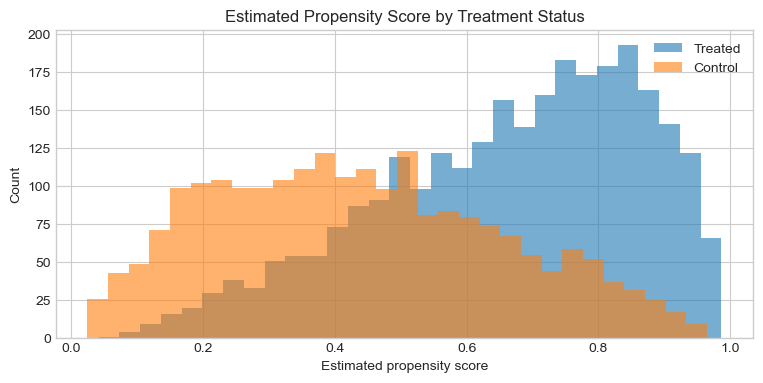

,mean,std,min,25%,50%,75%,max
college,,,,,,,
0,0.4350,0.2161,0.0242,0.2601,0.4213,0.5908,0.9645
1,0.6629,0.2006,0.0413,0.5243,0.6969,0.8254,0.9867


,count
Estimated scores below 0.05,19
Estimated scores above 0.95,84


In [8]:
logit_model = smf.logit(
    "college ~ pretest + parent_college + urban + female",
    data=df,
).fit(disp=False)

df["pscore_hat"] = logit_model.predict(df)

overlap_summary = df.groupby("college")["pscore_hat"].describe()[["mean", "std", "min", "25%", "50%", "75%", "max"]]
extreme_counts = pd.Series(
    {
        "Estimated scores below 0.05": int((df["pscore_hat"] < 0.05).sum()),
        "Estimated scores above 0.95": int((df["pscore_hat"] > 0.95).sum()),
    }
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df.loc[df["college"] == 1, "pscore_hat"], bins=30, alpha=0.6, label="Treated")
ax.hist(df.loc[df["college"] == 0, "pscore_hat"], bins=30, alpha=0.6, label="Control")
ax.set_title("Estimated Propensity Score by Treatment Status")
ax.set_xlabel("Estimated propensity score")
ax.set_ylabel("Count")
ax.legend()
plt.show()

display(overlap_summary)
display(extreme_counts.to_frame("count"))

## 6. Exercise: IPW and final comparison table

Now compare everything in one place.

Focus on interpretation, not only numerical closeness.

- Which rows are noncausal?
- Which rows target the ATE?
- Which rows target the ATT?
- Which row is causal but regression-weighted rather than population-weighted?

In [9]:
trimmed = df.loc[df["pscore_hat"].between(0.05, 0.95)].copy()

comparison = pd.DataFrame(
    {
        "estimate": [
            df["tau"].mean(),
            df.loc[df["college"] == 1, "tau"].mean(),
            summary["Raw treated-control difference"],
            ols_naive.params["college"],
            ols_controls.params["college"],
            ols_bad_control.params["college"],
            match_ate,
            match_att,
            ols_saturated.params["college"],
            ipw_ate(df),
            ipw_att(df),
            ipw_ate(trimmed),
        ],
        "interpretation": [
            "True ATE",
            "True ATT",
            "Observed difference in means; noncausal",
            "Naive regression; noncausal",
            "Controlled regression; causal weighted average under CIA",
            "Bad-control regression; distorted by post-treatment conditioning",
            "Matching estimator for ATE",
            "Matching estimator for ATT",
            "Regression-weighted causal average",
            "IPW estimator for ATE",
            "IPW estimator for ATT",
            "IPW ATE after trimming weak-support observations",
        ],
    },
    index=[
        "True ATE",
        "True ATT",
        "Raw mean difference",
        "Naive OLS",
        "OLS with good controls",
        "OLS with bad control",
        "Exact matching ATE",
        "Exact matching ATT",
        "Saturated regression",
        "IPW ATE",
        "IPW ATT",
        "Trimmed IPW ATE",
    ],
)

comparison

,estimate,interpretation
True ATE,0.1171,True ATE
True ATT,0.1286,True ATT
Raw mean difference,0.5757,Observed difference in means; noncausal
Naive OLS,0.5757,Naive regression; noncausal
OLS with good controls,0.1148,Controlled regression; causal weighted average...
OLS with bad control,0.1136,Bad-control regression; distorted by post-trea...
Exact matching ATE,0.1705,Matching estimator for ATE
Exact matching ATT,0.1777,Matching estimator for ATT
Saturated regression,0.1601,Regression-weighted causal average
IPW ATE,0.0786,IPW estimator for ATE


## 7. Short write-up prompts

Write short answers to these five questions.

1. Why is the raw mean difference not a causal estimate here?
2. Why does the coefficient move after adding good controls?
3. Why can matching ATT, matching ATE, and saturated regression differ without contradicting each other?
4. What exactly made `occupation_score` a bad control?
5. What did the overlap diagnostics suggest about the credibility of the IPW estimates?